--- INITIATING: 04 MONTE CARLO RELIABILITY SIMULATION ---

⏳ Step 1: Please upload your TRAINING Dataset CSV...


Saving Full detail-Full_Detail.csv to Full detail-Full_Detail (2).csv
⏳ Step 2: Please upload your TESTING Dataset CSV...


Saving Testing_18BH.csv to Testing_18BH (2).csv
🎲 Executing 60,000 statistical permutations (20% Input COV)...


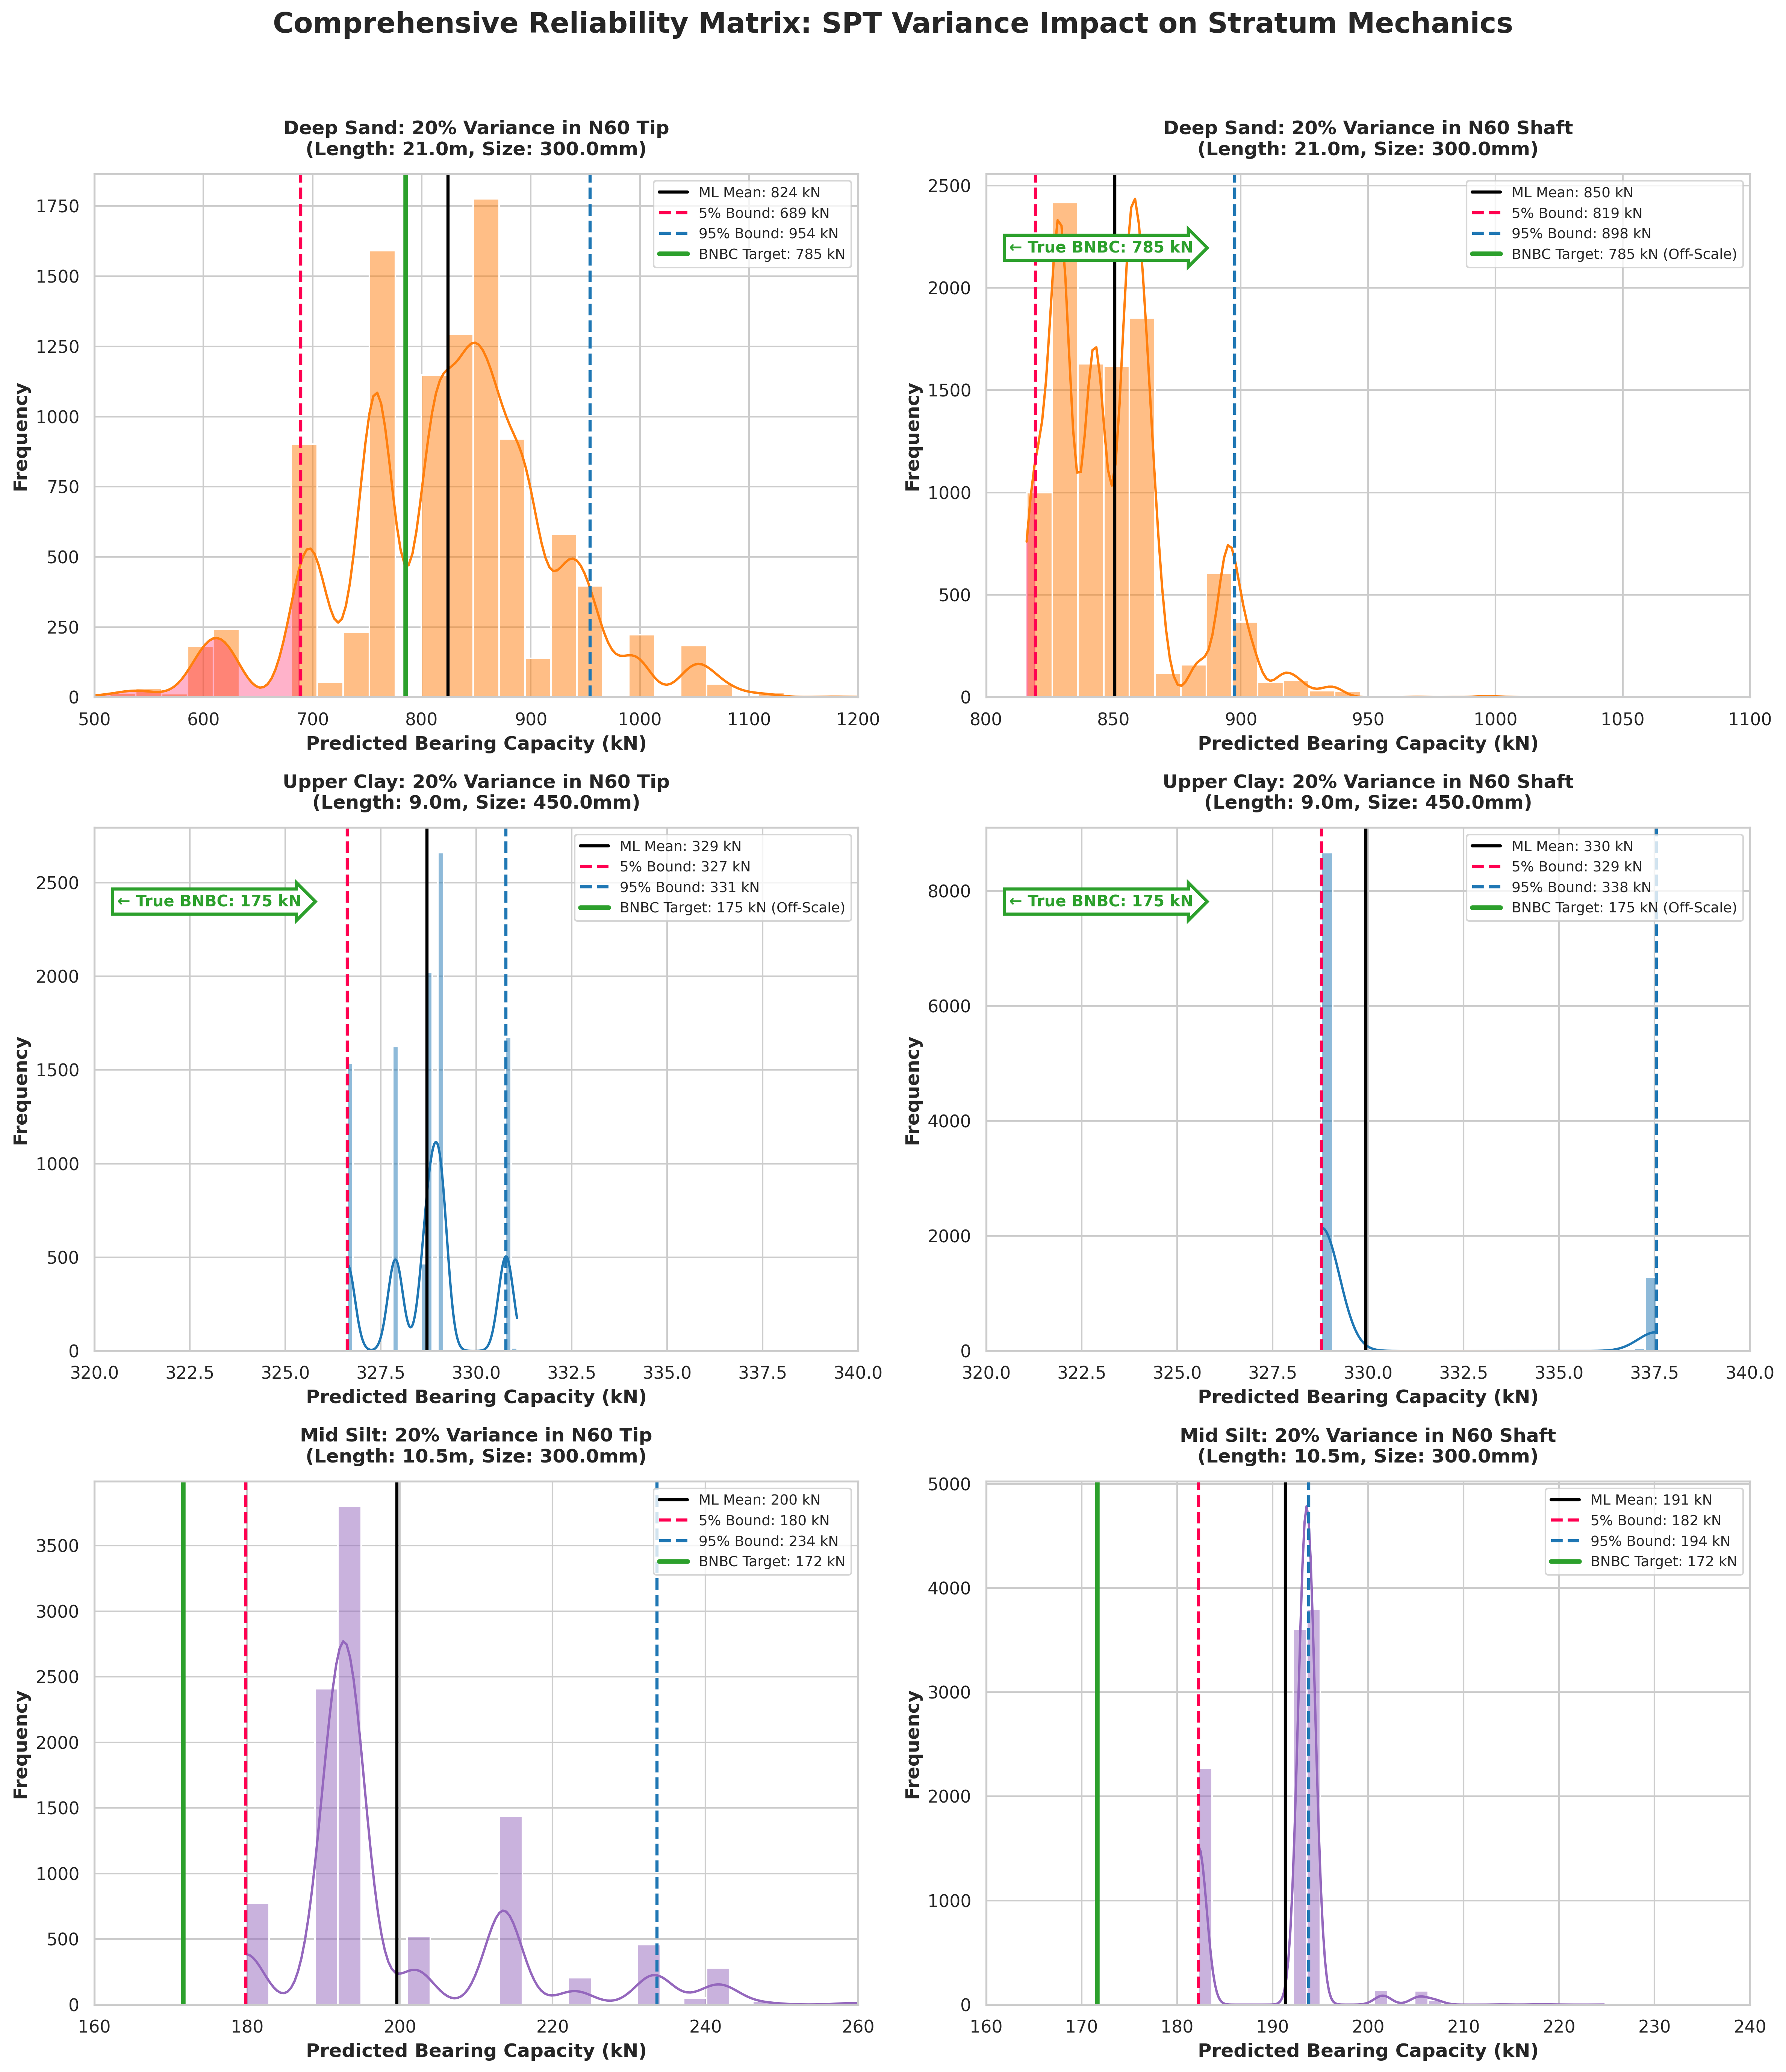

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBRegressor

print("--- INITIATING: 04 MONTE CARLO RELIABILITY SIMULATION ---\n")

# ==========================================
# 1. DIRECT FILE UPLOAD
# ==========================================
try:
    from google.colab import files
    import io
    print("⏳ Step 1: Please upload your TRAINING Dataset CSV...")
    uploaded_train = files.upload()
    train_filename = list(uploaded_train.keys())[0]
    df_train = pd.read_csv(io.BytesIO(uploaded_train[train_filename]))

    print("⏳ Step 2: Please upload your TESTING Dataset CSV...")
    uploaded_test = files.upload()
    test_filename = list(uploaded_test.keys())[0]
    df_test = pd.read_csv(io.BytesIO(uploaded_test[test_filename]))
except ImportError:
    train_filename = input("Enter TRAINING CSV file: ")
    df_train = pd.read_csv(train_filename)
    test_filename = input("Enter TESTING CSV file: ")
    df_test = pd.read_csv(test_filename)

df_train.columns = df_train.columns.str.strip()
df_test.columns = df_test.columns.str.strip()

# ==========================================
# 2. PREPROCESSING & ALIGNMENT
# ==========================================
df_train_encoded = pd.get_dummies(df_train, columns=['Soil_Type'], dtype=int)
df_test_encoded = pd.get_dummies(df_test, columns=['Soil_Type'], dtype=int)
df_train_encoded, df_test_encoded = df_train_encoded.align(df_test_encoded, join='left', axis=1, fill_value=0)

feature_cols = ['Pile_Length_m', 'Pile_Size_mm', 'N60_Shaft', 'N60_Tip']
soil_cols = [col for col in df_train_encoded.columns if 'Soil_Type_' in col]
X_cols = feature_cols + soil_cols

X_train = df_train_encoded[X_cols]
y_train = df_train_encoded['Q_gross_kN']
X_test = df_test_encoded[X_cols]
y_test = df_test_encoded['Q_gross_kN']

# ==========================================
# 3. TRAIN CHAMPION XGBOOST MODEL
# ==========================================
xgb_model = XGBRegressor(n_estimators=1000, learning_rate=0.05, max_depth=5, random_state=42, n_jobs=-1)
xgb_model.fit(X_train, y_train)

# ==========================================
# 4. BASE PILE SELECTION
# ==========================================
def get_pile_and_target(df_X, df_y, condition, sort_cols, fallback_idx):
    subset_X = df_X[condition]
    if not subset_X.empty:
        idx = subset_X.sort_values(by=sort_cols).index[0]
    else:
        idx = df_X.index[fallback_idx]
    return df_X.loc[idx].copy(), df_y.loc[idx]

base_sand, target_sand = get_pile_and_target(X_test, y_test, (X_test['Pile_Length_m'] > 20), ['Pile_Length_m', 'N60_Tip'], 0)
base_clay, target_clay = get_pile_and_target(X_test, y_test, (X_test['Pile_Length_m'] >= 7.5) & (X_test['Pile_Length_m'] <= 12.0), ['N60_Shaft'], len(X_test)//4)
base_silt, target_silt = get_pile_and_target(X_test, y_test, (X_test['Pile_Length_m'] >= 10.0) & (X_test['Pile_Length_m'] <= 18.0), ['N60_Tip'], len(X_test)//2)

# ==========================================
# 5. MONTE CARLO SIMULATION ENGINE
# ==========================================
print("🎲 Executing 60,000 statistical permutations (20% Input COV)...")
n_sims = 10000
input_cov = 0.20
np.random.seed(42)

def run_mc(base_pile, target_feature):
    df_sim = pd.DataFrame([base_pile] * n_sims)
    mean_val = base_pile[target_feature]
    std_dev = mean_val * input_cov
    df_sim[target_feature] = np.random.normal(loc=mean_val, scale=std_dev, size=n_sims)
    df_sim[target_feature] = np.maximum(df_sim[target_feature], 0.1)
    return xgb_model.predict(df_sim)

sims = {
    "Sand_Tip": run_mc(base_sand, 'N60_Tip'),
    "Sand_Shaft": run_mc(base_sand, 'N60_Shaft'),
    "Clay_Tip": run_mc(base_clay, 'N60_Tip'),
    "Clay_Shaft": run_mc(base_clay, 'N60_Shaft'),
    "Silt_Tip": run_mc(base_silt, 'N60_Tip'),
    "Silt_Shaft": run_mc(base_silt, 'N60_Shaft')
}

# ==========================================
# 6. HIGH-RESOLUTION PLOTTING ENGINE (MANUAL AXES)
# ==========================================
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(3, 2, figsize=(16, 18))

def plot_mc(ax, simulated_data, title, color, bnbc_target, x_range):
    mean_cap = np.mean(simulated_data)
    p5 = np.percentile(simulated_data, 5)
    p95 = np.percentile(simulated_data, 95)

    x_lower, x_upper = x_range

    sns.histplot(simulated_data, kde=True, stat="count", color=color, alpha=0.5, bins=30, ax=ax)
    ax.set_xlim(x_lower, x_upper)

    ax.axvline(mean_cap, color='black', linestyle='-', lw=2, label=f'ML Mean: {mean_cap:.0f} kN')
    ax.axvline(p5, color='#ff0051', linestyle='--', lw=2, label=f'5% Bound: {p5:.0f} kN')
    ax.axvline(p95, color='#1f77b4', linestyle='--', lw=2, label=f'95% Bound: {p95:.0f} kN')

    if x_lower <= bnbc_target <= x_upper:
        ax.axvline(bnbc_target, color='#2ca02c', linestyle='-', lw=3, label=f'BNBC Target: {bnbc_target:.0f} kN')
    else:
        ax.plot([], [], color='#2ca02c', linestyle='-', lw=3, label=f'BNBC Target: {bnbc_target:.0f} kN (Off-Scale)')
        if bnbc_target < x_lower:
            ax.annotate(f'← True BNBC: {bnbc_target:.0f} kN', xy=(0.03, 0.85), xycoords='axes fraction',
                        fontsize=10, color='#2ca02c', fontweight='bold',
                        bbox=dict(boxstyle="rarrow,pad=0.3", fc="white", ec="#2ca02c", lw=2))
        else:
            ax.annotate(f'True BNBC: {bnbc_target:.0f} kN →', xy=(0.97, 0.85), xycoords='axes fraction',
                        fontsize=10, color='#2ca02c', fontweight='bold', ha='right',
                        bbox=dict(boxstyle="larrow,pad=0.3", fc="white", ec="#2ca02c", lw=2))

    kde_lines = ax.lines[0]
    if kde_lines:
        kde_x, kde_y = kde_lines.get_data()
        ax.fill_between(kde_x, kde_y, where=(kde_x < p5), color='#ff0051', alpha=0.3)

    ax.set_title(title, fontweight='bold', pad=12, fontsize=12)
    ax.set_xlabel("Predicted Bearing Capacity (kN)", fontweight='bold')
    ax.set_ylabel("Frequency", fontweight='bold')
    ax.legend(loc='upper right', fontsize=9, frameon=True)

def make_title(soil, feature, pile):
    return f"{soil}: 20% Variance in {feature}\n(Length: {pile['Pile_Length_m']}m, Size: {pile['Pile_Size_mm']}mm)"

plot_mc(axes[0, 0], sims["Sand_Tip"], make_title("Deep Sand", "N60 Tip", base_sand), "#ff7f0e", target_sand, x_range=(500, 1200))
plot_mc(axes[0, 1], sims["Sand_Shaft"], make_title("Deep Sand", "N60 Shaft", base_sand), "#ff7f0e", target_sand, x_range=(800, 1100))

plot_mc(axes[1, 0], sims["Clay_Tip"], make_title("Upper Clay", "N60 Tip", base_clay), "#1f77b4", target_clay, x_range=(320, 340))
plot_mc(axes[1, 1], sims["Clay_Shaft"], make_title("Upper Clay", "N60 Shaft", base_clay), "#1f77b4", target_clay, x_range=(320, 340))

plot_mc(axes[2, 0], sims["Silt_Tip"], make_title("Mid Silt", "N60 Tip", base_silt), "#9467bd", target_silt, x_range=(160, 260))
plot_mc(axes[2, 1], sims["Silt_Shaft"], make_title("Mid Silt", "N60 Shaft", base_silt), "#9467bd", target_silt, x_range=(160, 240))

plt.suptitle("Comprehensive Reliability Matrix: SPT Variance Impact on Stratum Mechanics", fontweight='bold', fontsize=18, y=1.02)
plt.tight_layout()
plt.show()